# Newtonian Nudging into Top Soil Layer — Fiji Example

Data assimilation experiment using the VAMPS stepwise Python interface.

## Design

1. **Open-loop (truth)** — run the Fiji Richards-equation model and store the top-layer θ profile.
2. **Synthetic observations** — add a small wet bias and random noise to simulate a remote-sensing retrieval (e.g. SAR-derived surface soil moisture, penetration ≈ first 3 nodes = 0–6 cm).
3. **Nudged run** — re-run the model but after each step apply Newtonian nudging to nodes 0–(`OBS_NODES`-1):

$$\theta_i^{\text{nudged}} = \theta_i + \alpha \cdot (\theta_i^{\text{obs}} - \theta_i^{\text{model}})$$

where $\alpha \in [0, 1]$ controls nudging strength (0 = no correction, 1 = full replacement).


In [1]:
import sys, os, copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, '..')
from vampspy import _vampscore, Model

FIJI_DIR = os.path.join('..', 'examples', 'fiji')
RNG      = np.random.default_rng(42)

# --- Nudging parameters ---
OBS_NODES  = 3      # number of top nodes to assimilate (node 0..OBS_NODES-1, 0-6 cm)
ALPHA      = 0.1    # nudging strength per step  [0 = none, 1 = full replacement]
OBS_BIAS   = -0.1   # wet bias added to truth (vol/vol)
OBS_SIGMA  = 0.015  # random noise std (vol/vol)


## 1. Load model config and prepare INI string

In [2]:
m = Model.from_file(os.path.join(FIJI_DIR, 'fiji.inp'), vampslib='../share')

cfg = copy.deepcopy(m.config)
cfg.setdefault('time', {})['steps'] = m.steps
cfg.setdefault('soil', {})['swredu'] = 3  # enable soil evaporation reduction by moisture
cfg['ts'] = {name: f'_array_{name}' for name in m.forcing}  # register forcing arrays
from vampspy._io import write_inp_str
ini_text = write_inp_str(cfg, '/dev/null', {}, firststep=1)

nlayers   = None   # determined after soil_init
steps     = m.steps
dz_cm     = 2.0
print(f"Fiji config loaded: steps={steps}")


Fiji config loaded: steps=61


## 2. Open-loop run (truth)

In [3]:
_vampscore.soil_init(ini_text, m.forcing, 1.0)
nlayers   = _vampscore.soil_nlayers()
depth_cm  = (np.arange(nlayers) + 0.5) * dz_cm

# Storage
theta_truth = np.zeros((steps, nlayers))
h_truth     = np.zeros((steps, nlayers))
volact_truth = np.zeros(steps)
qbot_truth   = np.zeros(steps)
rootex_truth = np.zeros(steps)   # qrot.sum() per step

for i in range(steps):
    _vampscore.soil_step(i)
    s = _vampscore.soil_state_current()
    theta_truth[i]  = s['theta']
    h_truth[i]      = s['h']
    volact_truth[i] = s['volact']
    qbot_truth[i]   = s['qbot']
    rootex_truth[i] = s['qrot'].sum()

final_truth = _vampscore.soil_state_current()
print(f"Open-loop done.  nlayers={nlayers}, mean top-node θ: {theta_truth[:, 0].mean():.4f}")


Open-loop done.  nlayers=77, mean top-node θ: 0.2355






+-----------------------------------------------------------------------------+
| time              |  running | to_go |   [masbal, it,   err, dt,water_cont] |
+-----------------------------------------------------------------------------+
|        61.000000  |    0 sec.|    0  |   [-0.002,  1,    0,0.002809,61.562] |


## 3. Synthetic observations

Simulate a remote-sensing retrieval by adding a wet bias and Gaussian noise
to the truth at nodes 0–(`OBS_NODES`-1).  The observation is clipped to
physically plausible bounds [θ_r, θ_s] — we use [0.05, 0.62] as safe limits.


In [4]:
# Mean top-node θ for bias/noise reference
theta_obs = theta_truth[:, :OBS_NODES].copy()
theta_obs += OBS_BIAS
theta_obs += RNG.normal(0.0, OBS_SIGMA, theta_obs.shape)
theta_obs  = np.clip(theta_obs, 0.05, 0.62)

print(f"Observation stats (nodes 0–{OBS_NODES-1}):")
print(f"  truth mean  : {theta_truth[:, :OBS_NODES].mean():.4f}")
print(f"  obs   mean  : {theta_obs.mean():.4f}  (bias ~ {OBS_BIAS:+.3f})")
print(f"  obs   std   : {theta_obs.std():.4f}")


Observation stats (nodes 0–2):
  truth mean  : 0.2320
  obs   mean  : 0.1312  (bias ~ -0.100)
  obs   std   : 0.0224


## 4. Nudged run

In [5]:
_vampscore.soil_init(ini_text, m.forcing, 1.0)

theta_nudged  = np.zeros((steps, nlayers))
h_nudged      = np.zeros((steps, nlayers))
volact_nudged = np.zeros(steps)
qbot_nudged   = np.zeros(steps)
rootex_nudged = np.zeros(steps)  # qrot.sum() per step
nudge_applied = np.zeros((steps, OBS_NODES))   # correction magnitude

for i in range(steps):
    _vampscore.soil_step(i)
    s = _vampscore.soil_state_current()

    # Apply Newtonian nudging to top OBS_NODES nodes
    for j in range(OBS_NODES):
        correction = ALPHA * (theta_obs[i, j] - s['theta'][j])
        nudge_applied[i, j] = correction
        _vampscore.soil_set_theta(j, s['theta'][j] + correction)

    # Read back updated state
    s2 = _vampscore.soil_state_current()
    theta_nudged[i]  = s2['theta']
    h_nudged[i]      = s2['h']
    volact_nudged[i] = s2['volact']
    qbot_nudged[i]   = s2['qbot']
    rootex_nudged[i] = s2['qrot'].sum()

final_nudged = _vampscore.soil_state_current()
print("Nudged run done.")
print(f"  Mean |correction| node 0: {np.abs(nudge_applied[:, 0]).mean():.4f} vol/vol")


Nudged run done.
  Mean |correction| node 0: 0.0064 vol/vol


|        61.000000  |    0 sec.|    0  |   [ 1.641,  1,    0,0.005345,61.051] |


## 5. Results

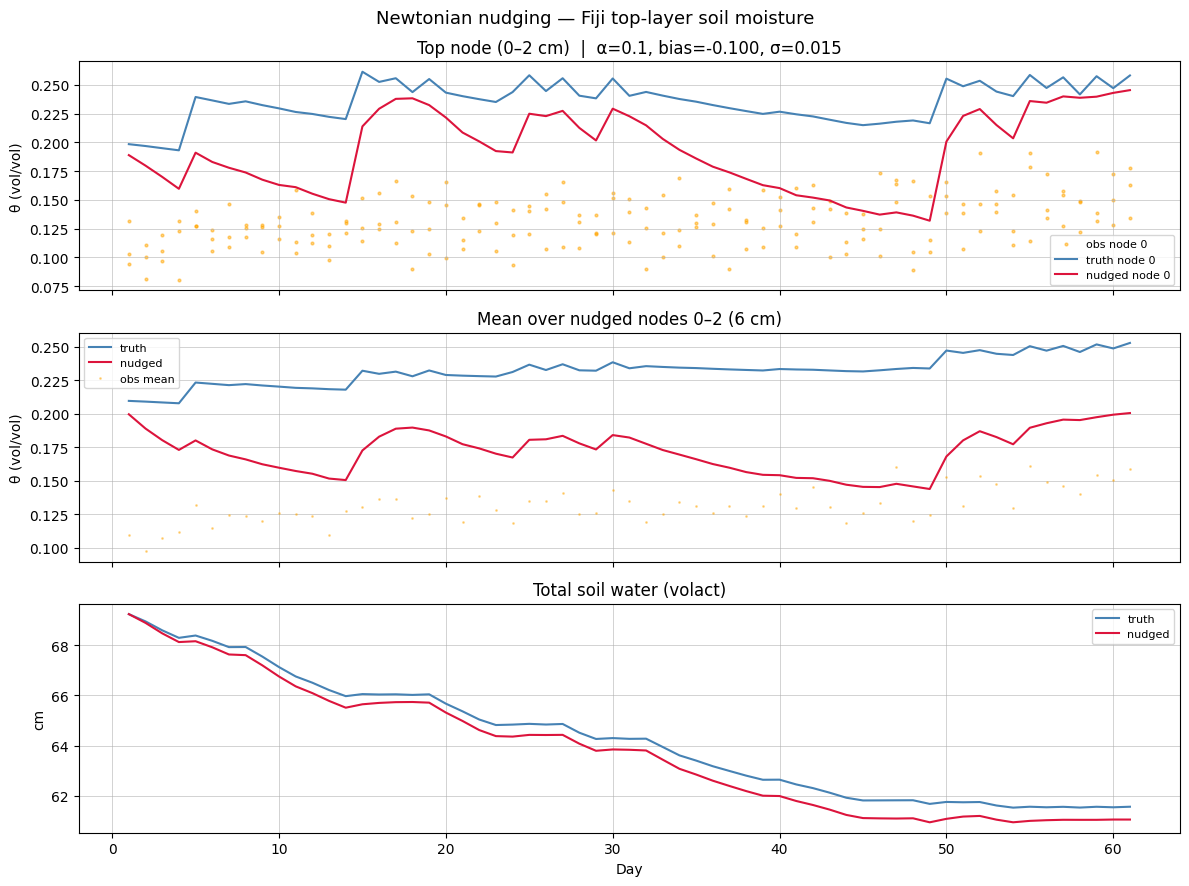

Saved da_nudging_timeseries.png


In [6]:
days = np.arange(1, steps + 1)

# ── Figure 1: time series of top-node θ ─────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Newtonian nudging — Fiji top-layer soil moisture', fontsize=13)

ax = axes[0]
for j in range(OBS_NODES):
    label = f'obs node {j}' if j == 0 else None
    ax.scatter(days, theta_obs[:, j], s=4, color='orange', alpha=0.5, label=label if j==0 else None)
ax.plot(days, theta_truth[:, 0],  color='steelblue',  lw=1.5, label='truth node 0')
ax.plot(days, theta_nudged[:, 0], color='crimson',    lw=1.5, label='nudged node 0')
ax.set_ylabel('θ (vol/vol)')
ax.set_title(f'Top node (0–{dz_cm:.0f} cm)  |  α={ALPHA}, bias={OBS_BIAS:+.3f}, σ={OBS_SIGMA:.3f}')
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4)

ax = axes[1]
ax.plot(days, theta_truth[:, :OBS_NODES].mean(axis=1),  color='steelblue', lw=1.5, label='truth')
ax.plot(days, theta_nudged[:, :OBS_NODES].mean(axis=1), color='crimson',   lw=1.5, label='nudged')
ax.plot(days, theta_obs.mean(axis=1), '.', ms=2, color='orange', alpha=0.4, label='obs mean')
ax.set_ylabel('θ (vol/vol)')
ax.set_title(f'Mean over nudged nodes 0–{OBS_NODES-1} ({OBS_NODES*dz_cm:.0f} cm)')
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4)

ax = axes[2]
ax.plot(days, volact_truth,  color='steelblue', lw=1.5, label='truth')
ax.plot(days, volact_nudged, color='crimson',   lw=1.5, label='nudged')
ax.set_ylabel('cm')
ax.set_xlabel('Day')
ax.set_title('Total soil water (volact)')
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4)

plt.tight_layout()
plt.savefig('da_nudging_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved da_nudging_timeseries.png')


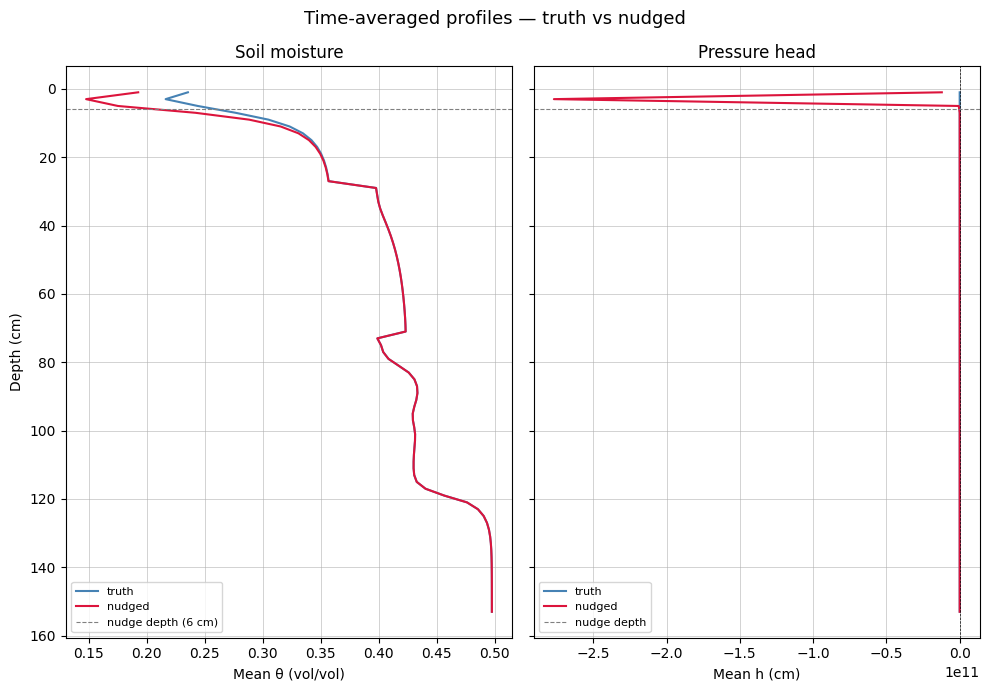

Saved da_nudging_profiles.png


In [7]:
# ── Figure 2: mean θ profiles  ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharey=True)
fig.suptitle('Time-averaged profiles — truth vs nudged', fontsize=13)

ax = axes[0]
ax.plot(theta_truth.mean(axis=0),  depth_cm, color='steelblue', lw=1.5, label='truth')
ax.plot(theta_nudged.mean(axis=0), depth_cm, color='crimson',   lw=1.5, label='nudged')
ax.axhline(OBS_NODES * dz_cm, color='gray', lw=0.8, ls='--', label=f'nudge depth ({OBS_NODES*dz_cm:.0f} cm)')
ax.invert_yaxis()
ax.set_xlabel('Mean θ (vol/vol)')
ax.set_ylabel('Depth (cm)')
ax.set_title('Soil moisture')
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4)

ax = axes[1]
ax.plot(h_truth.mean(axis=0),  depth_cm, color='steelblue', lw=1.5, label='truth')
ax.plot(h_nudged.mean(axis=0), depth_cm, color='crimson',   lw=1.5, label='nudged')
ax.axvline(0, color='k', lw=0.5, ls='--')
ax.axhline(OBS_NODES * dz_cm, color='gray', lw=0.8, ls='--', label=f'nudge depth')
ax.set_xlabel('Mean h (cm)')
ax.set_title('Pressure head')
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4)

plt.tight_layout()
plt.savefig('da_nudging_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved da_nudging_profiles.png')


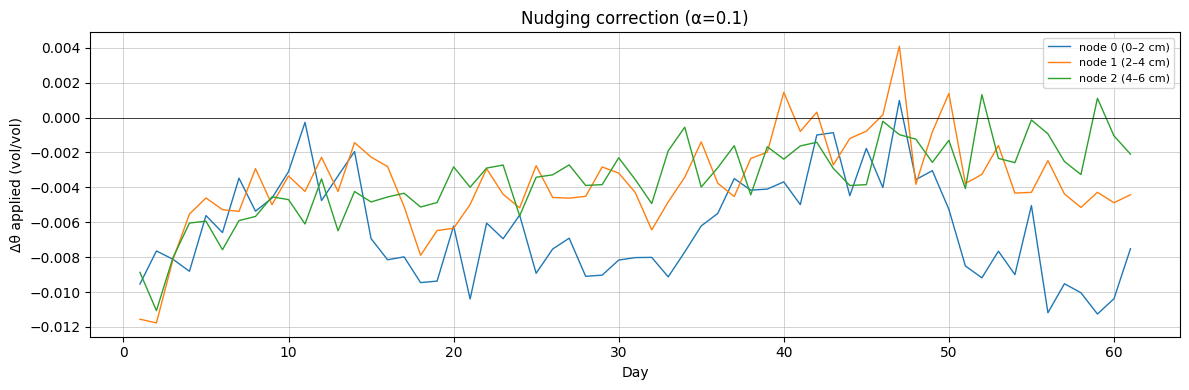

Saved da_nudging_correction.png

                                    RMSE      Bias
  Open-loop vs obs                0.1016    +0.1007
  Nudged vs obs                     0.0483    +0.0407


In [8]:
# ── Figure 3: nudge correction magnitude per node ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
for j in range(OBS_NODES):
    ax.plot(days, nudge_applied[:, j], lw=1, label=f'node {j} ({j*dz_cm:.0f}–{(j+1)*dz_cm:.0f} cm)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Day')
ax.set_ylabel('Δθ applied (vol/vol)')
ax.set_title(f'Nudging correction (α={ALPHA})')
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4)
plt.tight_layout()
plt.savefig('da_nudging_correction.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved da_nudging_correction.png')

# Summary stats
rmse_before = np.sqrt(((theta_truth[:, :OBS_NODES] - theta_obs)**2).mean())
rmse_after  = np.sqrt(((theta_nudged[:, :OBS_NODES] - theta_obs)**2).mean())
bias_truth  = (theta_truth[:, :OBS_NODES] - theta_obs).mean()
bias_nudged = (theta_nudged[:, :OBS_NODES] - theta_obs).mean()
print(f"\n{'':30s}  {'RMSE':>8s}  {'Bias':>8s}")
print(f"  {'Open-loop vs obs':30s}  {rmse_before:.4f}    {bias_truth:+.4f}")
print(f"  {'Nudged vs obs':30s}    {rmse_after:.4f}    {bias_nudged:+.4f}")


## 6. Water balance comparison

All terms in cm over the simulation period.  The nudging correction is a synthetic source/sink; positive = water added to the top nodes.


In [9]:
# ── Water balance table ───────────────────────────────────────────────────────
import pandas as pd
from IPython.display import display

# Cumulative nudge correction: Δθ summed over nudged nodes × dz
nudge_cm    = nudge_applied.sum(axis=1) * dz_cm
total_nudge = nudge_cm.sum()

# Root extraction: sum of per-step qrot.sum()
# qrot[j] is in cm d⁻¹ per layer (not per cm depth); one timestep = 1 day
cum_rootex_truth  = rootex_truth.sum()
cum_rootex_nudged = rootex_nudged.sum()

# Bottom drainage: qbot is negative downward → flip sign for "out"
cum_qbot_truth    = -qbot_truth.sum()
cum_qbot_nudged   = -qbot_nudged.sum()

# Storage change: final volact minus volact at step 0
ds_truth   = final_truth["volact"]  - volact_truth[0]
ds_nudged  = final_nudged["volact"] - volact_nudged[0]

rows = {
    "Precipitation (gross)":        [final_truth["cumprec"],  final_nudged["cumprec"]],
    "Interception":                  [final_truth["cumintc"],  final_nudged["cumintc"]],
    "Net precip to soil":            [final_truth["cumprec"] - final_truth["cumintc"],
                                      final_nudged["cumprec"] - final_nudged["cumintc"]],
    "Root extraction (Σqrot)":       [cum_rootex_truth,         cum_rootex_nudged],
    "Transpiration (cumtra)":        [final_truth["cumtra"],   final_nudged["cumtra"]],
    "Soil evaporation":              [final_truth["cumeva"],   final_nudged["cumeva"]],
    "Bottom drainage":               [cum_qbot_truth,           cum_qbot_nudged],
    "Total out (qrot+eva+bot)":      [cum_rootex_truth + final_truth["cumeva"] + cum_qbot_truth,
                                      cum_rootex_nudged + final_nudged["cumeva"] + cum_qbot_nudged],
    "ΔStorage (last − first step)":  [ds_truth,                 ds_nudged],
    "Nudge correction (total)":      [0.0,                      total_nudge],
    "Mass balance error":            [final_truth["masbal"],   final_nudged["masbal"]],
}

df = pd.DataFrame(rows, index=["Open-loop (truth)", "Nudged"]).T
df.index.name = "Component (cm)"
df["Δ (nudged − truth)"] = df["Nudged"] - df["Open-loop (truth)"]

caption = (f"Water balance summary  |  α={ALPHA}, bias={OBS_BIAS:+.3f}, "
           f"σ={OBS_SIGMA:.3f}, nodes 0–{OBS_NODES-1} (0–{OBS_NODES*dz_cm:.0f} cm)")
display(df.style.format("{:.4f}").set_caption(caption))

print()
print(df.to_string(float_format=lambda x: f"{x:+.4f}"))
print()
print("Notes:")
print("  Root extraction (Σqrot) : actual soil-side extraction, Feddes-stress limited.")
print("    Differs between runs because nudging relaxes stress in subsequent steps.")
print("  Transpiration (cumtra)  : accumulated by the top-system before nudging is applied;")
print("    identical in both runs — the nudge cannot retroactively change already-counted fluxes.")
print("  Soil evaporation        : same reason as cumtra — counted before the nudge.")
print(f"  Root extraction increases by {cum_rootex_nudged - cum_rootex_truth:+.4f} cm in the nudged run.")


,Open-loop (truth),Nudged,Δ (nudged − truth)
Component (cm),,,
Precipitation (gross),25.7675,25.7675,0.0000
Interception,4.8862,4.8862,0.0000
Net precip to soil,20.8814,20.8814,0.0000
Root extraction (Σqrot),7.9484,7.9480,-0.0004
Transpiration (cumtra),15.0456,15.0456,0.0000
Soil evaporation,20.7536,19.6233,-1.1302
Bottom drainage,0.0079,0.0079,0.0000
Total out (qrot+eva+bot),28.7099,27.5792,-1.1307
ΔStorage (last − first step),-7.6785,-8.1897,-0.5112



                              Open-loop (truth)   Nudged  Δ (nudged − truth)
Component (cm)                                                              
Precipitation (gross)                  +25.7675 +25.7675             +0.0000
Interception                            +4.8862  +4.8862             +0.0000
Net precip to soil                     +20.8814 +20.8814             +0.0000
Root extraction (Σqrot)                 +7.9484  +7.9480             -0.0004
Transpiration (cumtra)                 +15.0456 +15.0456             +0.0000
Soil evaporation                       +20.7536 +19.6233             -1.1302
Bottom drainage                         +0.0079  +0.0079             +0.0000
Total out (qrot+eva+bot)               +28.7099 +27.5792             -1.1307
ΔStorage (last − first step)            -7.6785  -8.1897             -0.5112
Nudge correction (total)                +0.0000  -1.6536             -1.6536
Mass balance error                      -0.0023  +1.6409             +1.643